# Reaching the bSSFP steady state

Balanced SSFP acquires with a short, constant TR and returns every gradient axis to zero net area
over each RF-to-RF interval. Nothing is spoiled, so the transverse magnetisation left at the end
of one repetition is carried into the next, and after enough repetitions the train settles into a
repeating pattern — the **steady state** — whose signal is high and whose contrast goes roughly as
$\sqrt{T_2/T_1}$. That is what makes the sequence useful for cardiac cine, non-contrast
angiography and fast abdominal imaging.

Getting to that steady state is a separate matter from building a balanced waveform, and this
notebook is about the difference.

```text
balanced waveform   zero net gradient area on each axis over the RF-to-RF interval
                    true of the first interval the scanner ever plays

steady state        the magnetisation has settled into the pattern the train drives it to
                    develops over many repetitions, and depends on T1, T2, flip angle and TR
```

The build notebook beside this one measured the first: zero net area on every axis of every
interval, the echo at the declared TE, the requested line at the echo. **None of that says
anything about the magnetisation.** A sequence can be balanced, legal and compiled and still be
nowhere near steady state — which is why a bSSFP acquisition is preceded by a start-up schedule,
and why the opening repetitions of an unprepared train are unusable.

Here the train is simulated: first on single voxels, where the signal of every repetition can be
read off directly, then as an image.

In [1]:
import os

# MRzero's inner loop takes every thread it is offered.  Hold it to four.
os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('MKL_NUM_THREADS', '4')

import contextlib
import os as _os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(4)
plt.rcParams['figure.dpi'] = 56

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'bssfp_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
FLIP_DEG = float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
PHASE_STEP = float(nominal['phase_step'])
STARTUP = int(nominal['startup'])
SEGMENTS = int(nominal['segments'])
TE_S, TR_S = float(nominal['te_s']), float(nominal['tr_s'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX

print(f'{NX} x {NY}, {FOV_MM:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'TE {TE_S * 1e3:.3f} ms   TR {TR_S * 1e3:.3f} ms   flip {FLIP_DEG:.0f} deg   '
      f'{STARTUP} start-up repetitions, {SEGMENTS} segments')
print(f'budget: {torch.get_num_threads()} torch threads')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


64 x 64, 250 mm, 6 mm slice
TE 3.425 ms   TR 6.850 ms   flip 40 deg   10 start-up repetitions, 4 segments
budget: 4 torch threads


## 1. One voxel, one line, every repetition sampled

To watch the magnetisation settle, the signal has to be read at *every* repetition — including
the ones a real acquisition discards. So this section builds its own sequence: the same kernel,
TR, flip angle and 180° phase alternation, but with `ky` held at the centre line and every
repetition acquired.

Holding `ky` fixed means each repetition sees an identical gradient history, so what changes
between them is the magnetisation and nothing else. It also means none of these readouts is an
imaging readout — they are navigators on the magnetisation, and they say so with a `NAV` label.

Three tissues, spanning what a brain acquisition contains:

| | T1 (ms) | T2 (ms) | $\sqrt{T_2/T_1}$ | $3\,T_1$ |
|---|---|---|---|---|
| white matter | 830 | 80 | 0.31 | 2.5 s |
| grey matter | 1330 | 110 | 0.29 | 4.0 s |
| CSF | 4000 | 2000 | 0.71 | 12 s |

The last column is the scale on which $T_1$ recovery finishes, and it is already a warning: at
TR = 6.85 ms, three $T_1$ of white matter is some 360 repetitions.

In [2]:
opts = pp.Opts(
    max_grad=24, grad_unit='mT/m', max_slew=120, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)
kernel = sc.modules.bSSFP2DTR(
    opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
    flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX,
)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12

N_REPS = 600          # 4.1 s of train: past three T1 for white and grey matter, not for CSF

#: These readouts all sit at one k-space address, so none of them is imaging.  Saying so keeps
#: them out of the duplicate-address check, which would otherwise be right to refuse the file.
NAV = pp.make_label(type='SET', label='NAV', value=1)


def ramp_kernels(n, final_deg=FLIP_DEG):
    """A linear flip-angle ramp, as the build notebook composes it."""
    return [
        sc.modules.bSSFP2DTR(
            opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
            flip_deg=final_deg * (k + 1) / (n + 1), bandwidth_hz_px=BANDWIDTH_HZ_PX,
            tr_s=TR_S,
        )
        for k in range(n)
    ]


def transient(path, *, startup=0, reps=N_REPS, line=None):
    """`reps` repetitions at one line, every one acquired, after `startup` ramp steps."""
    line = CENTER_LINE if line is None else line
    out, at, n = sc.LogicBlock('transient'), 0.0, 0
    for rep in [*ramp_kernels(startup), *([kernel] * reps)]:
        out.add(at, rep(line=line, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + rep.tr_s, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return n


n_plain = transient(SEQ_DIR / 'bssfp_transient_plain.seq', startup=0)
n_ramp = transient(SEQ_DIR / 'bssfp_transient_ramp.seq', startup=STARTUP)
print(f'plain  {n_plain} repetitions, {n_plain * TR_S:.2f} s')
print(f'ramp   {n_ramp} repetitions, {n_ramp * TR_S:.2f} s ({STARTUP} of them the ramp)')

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_34494/926315080.py:38: SeqCraftWarning: 600 blocks over the vector-norm limit (legal on real amplifiers): transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 24.810 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 31.660 ms) (+595 more sites)
  sc.compile(out, opts, name=path.stem).write(str(path))


plain  600 repetitions, 4.11 s
ramp   610 repetitions, 4.18 s (10 of them the ramp)


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_34494/926315080.py:38: SeqCraftWarning: 610 blocks over the vector-norm limit (legal on real amplifiers): transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 24.810 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 31.660 ms) (+605 more sites)
  sc.compile(out, opts, name=path.stem).write(str(path))


In [3]:
TISSUES = {
    'white matter': dict(T1=0.83, T2=0.080),
    'grey matter':  dict(T1=1.33, T2=0.110),
    'CSF':          dict(T1=4.00, T2=2.000),
}


def one_voxel(T1, T2, B0=0.0):
    """A single on-resonance spin, so each repetition returns one complex number."""
    return mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3, D=0.0, B0=B0,
        voxel_size=0.1, voxel_shape='box',
    ).build()


@contextlib.contextmanager
def quiet():
    """
    Silence the solver's per-call timing log.

    It is written from MRzero's Rust extension straight to file descriptor 1, so redirecting
    Python's ``sys.stdout`` does not catch it -- the descriptor itself has to be moved.
    """
    saved = _os.dup(1)
    null = _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def echo_train(path, obj):
    """|signal| at the echo sample of each repetition."""
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=200, min_state_mag=1e-5)
        signal = np.asarray(mr0.execute_graph(graph, seq, obj, print_progress=False).cpu())
    rows = signal.reshape(-1, int(kernel.ro.adc.num_samples))
    return rows[:, kernel.ro.echo_sample(0)]


plain = {name: echo_train(SEQ_DIR / 'bssfp_transient_plain.seq', one_voxel(**t))
         for name, t in TISSUES.items()}
ramped = {name: echo_train(SEQ_DIR / 'bssfp_transient_ramp.seq', one_voxel(**t))
          for name, t in TISSUES.items()}
print(f'{len(plain)} tissues x 2 trains of {n_plain} and {n_ramp} repetitions')

3 tissues x 2 trains of 600 and 610 repetitions


### The approach to steady state

Every repetition below plays an identical, balanced waveform. The signal is not identical,
because the magnetisation is still moving.

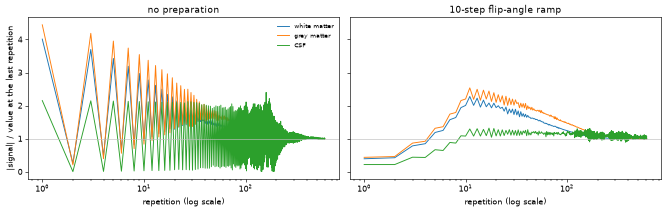

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, (title, data) in zip(axes, (('no preparation', plain),
                                    (f'{STARTUP}-step flip-angle ramp', ramped))):
    for name, s in data.items():
        ax.plot(np.arange(len(s)) + 1, np.abs(s) / np.abs(s[-1]), lw=1.2, label=name)
    ax.axhline(1.0, color='0.75', lw=0.8)
    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel('repetition (log scale)')
axes[0].set_ylabel('|signal| / value at the last repetition')
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [5]:
def within(s, tol=0.05):
    """First repetition after which |S| stays within `tol` of its final value, or None."""
    final = np.abs(s[-1])
    bad = np.nonzero(np.abs(np.abs(s) - final) / final > tol)[0]
    n = int(bad[-1]) + 2 if len(bad) else 1
    return n if n <= len(s) else None


marks = (1, 10, 50, 100, 300)
print(f'{"tissue":14}{"3*T1 (TRs)":>11}' + ''.join(f'{f"rep {m}":>9}' for m in marks)
      + f'{"within 5%":>11}')
for label, data in (('no preparation', plain), ('flip-angle ramp', ramped)):
    print(f'\n-- {label}, |S| relative to the last repetition')
    for name, t in TISSUES.items():
        s = data[name]
        final = np.abs(s[-1])
        got = within(s)
        print(f'{name:14}{3 * t["T1"] / TR_S:11.0f}'
              + ''.join(f'{np.abs(s[m - 1]) / final:9.2f}' for m in marks)
              + (f'{got:11d}' if got else f'{"> " + str(len(s)):>11}'))
print(f'\n{N_REPS} repetitions is {N_REPS * TR_S:.2f} s of train')

tissue         3*T1 (TRs)    rep 1   rep 10   rep 50  rep 100  rep 300  within 5%

-- no preparation, |S| relative to the last repetition
white matter          364     4.01     0.95     1.39     1.19     1.01        175
grey matter           582     4.44     0.84     1.60     1.39     1.03        267
CSF                  1752     2.15     0.03     0.15     0.10     0.90        468

-- flip-angle ramp, |S| relative to the last repetition
white matter          364     0.40     2.01     1.59     1.24     1.01        188
grey matter           582     0.44     2.20     1.84     1.47     1.04        283
CSF                  1752     0.22     1.08     1.15     1.19     1.15        610

600 repetitions is 4.11 s of train


**The waveform was balanced in every one of those repetitions, and the magnetisation was settled
in none of the early ones.** An unprepared train opens around four times above its final value,
falls below it, overshoots again, and converges slowly.

The flip-angle ramp does one thing clearly: the first repetition arrives at a fraction of the
final value instead of several times above it, so the largest excursion is gone. What it does
**not** do here is settle sooner — the "within 5%" column is slightly *later* with the ramp than
without it. The ramp reshapes the opening transient; the convergence underneath is set by the
tissue and the protocol, and the ramp does not change those.

CSF does not settle inside this window at all: $3\,T_1$ is 12 s where the train is 4 s, so its
column is a measurement of how far it has got rather than of where it ends up.

These numbers are for these three tissues at this flip angle and this TR, in this simulator. They
are what this ramp does here, not a count of start-up repetitions that transfers to another
protocol — and only one schedule is simulated. A single half-angle pulse half a TR before the
train is another common choice and is not measured here.

Two things that are **not** evidence of steady state, and that the build notebook establishes
instead:

```text
M0 = 0 over every RF-to-RF interval     the waveform is balanced
timing is legal and the file compiles   the sequence can be played
```

Both are true from repetition 1 of every train above.

### Off-resonance: the other thing TE = TR/2 is for

Because nothing is spoiled, phase accrued from off-resonance during one TR is carried into the
next, so the steady state is a function of the off-resonance angle per TR,
$\theta = 2\pi\,\Delta f\,\mathrm{TR}$. It collapses where $\theta$ approaches $\pm\pi$ — the dark
bands bSSFP is known for, spaced $1/\mathrm{TR}$ apart in frequency.

White and grey matter only: CSF has not settled by the end of this train, so a steady-state
response is not a thing that can be read off it here.

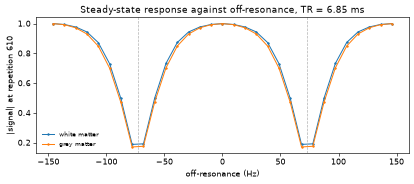

offsets sampled every 9.7 Hz; +/- 1/(2 TR) = 73.0 Hz
white matter   deepest sampled point at  -77.9 Hz, 0.50 grid steps from -1/(2 TR)
grey matter    deepest sampled point at  -77.9 Hz, 0.50 grid steps from -1/(2 TR)


In [6]:
offsets_hz = np.linspace(-1.0 / TR_S, 1.0 / TR_S, 31)
profile = {
    name: np.array([
        np.abs(echo_train(SEQ_DIR / 'bssfp_transient_ramp.seq', one_voxel(**t, B0=f))[-1])
        for f in offsets_hz
    ])
    for name, t in TISSUES.items() if name != 'CSF'
}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for name, s in profile.items():
    ax.plot(offsets_hz, s / s.max(), lw=1.3, marker='.', ms=4, label=name)
for edge in (-0.5 / TR_S, 0.5 / TR_S):
    ax.axvline(edge, color='0.7', ls='--', lw=0.9)
ax.set_xlabel('off-resonance (Hz)')
ax.set_ylabel('|signal| at repetition ' + str(n_ramp))
ax.set_title(f'Steady-state response against off-resonance, TR = {TR_S * 1e3:.2f} ms')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

step = offsets_hz[1] - offsets_hz[0]
print(f'offsets sampled every {step:.1f} Hz; +/- 1/(2 TR) = {0.5 / TR_S:.1f} Hz')
for name, s in profile.items():
    null = offsets_hz[np.argmin(s)]
    print(f'{name:14} deepest sampled point at {null:+6.1f} Hz, '
          f'{abs(abs(null) - 0.5 / TR_S) / step:.2f} grid steps from -1/(2 TR)')

The passband is centred on resonance and the response falls away towards $\pm 1/(2\,\mathrm{TR})$,
where the off-resonance phase per TR reaches $\pm\pi$ — the placement the 180° alternation
produces. The two curves differ in how flat the passband is, which is where $T_1$, $T_2$ and the
flip angle enter.

This is measured on single on-resonance-plus-offset voxels with no intravoxel spread; a real
voxel contains a distribution of off-resonance, so a band in an image is an average over that
distribution rather than the curve above.

## 2. The acquisition, reconstructed

Now the two sequences the build notebook wrote — a continuous acquisition and a four-segment one —
against a BrainWeb slab prepared in `../phantom.py`.

The phantom is a **slab** rather than a single slice because the excitation's selection gradient
dephases across the slice; with one voxel along z there is nothing to average that dephasing over
and the simulator returns zero.

In [7]:
NZ, N_COILS = 4, 8
obj = ph.built(matrix=NX, nz=NZ, n_coils=N_COILS)
lines = [int(v) for v in nominal['lines']]

print(f'{NX} x {NX} x {NZ} voxels, {N_COILS} coils; the sequence excites '
      f'{THICKNESS_MM:.0f} mm at isocentre')
print(f'{len(lines)} lines, acquired in the order they were written')

64 x 64 x 4 voxels, 8 coils; the sequence excites 6 mm at isocentre
64 lines, acquired in the order they were written


In [8]:
def to_grid(signal, lines):
    """``(coil, ky, kx)`` from the flat signal: one row per repetition, in acquisition order."""
    n = int(kernel.ro.adc.num_samples)
    rows = np.asarray(signal).reshape(len(lines), n, -1)
    out = np.zeros((rows.shape[2], NY, NX), dtype=np.complex64)
    for index, line in enumerate(lines):
        out[:, line, :] = rows[index].T
    return out


def acquire(path, obj, lines):
    """Play a file and return ``(k-space, root-sum-of-squares image)``."""
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, seq, obj, print_progress=False).cpu())
    k = to_grid(signal, lines)
    images = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1))), axes=(-2, -1))
    return k, np.sqrt((np.abs(images) ** 2).sum(axis=0))


k_cont, image = acquire(SEQ_DIR / 'bssfp_2d.seq', obj, lines)
k_seg, segmented = acquire(SEQ_DIR / 'bssfp_2d_segmented.seq', obj, lines)
print(f'image {image.shape}, k-space {k_cont.shape}')

image (64, 64), k-space (8, 64, 64)


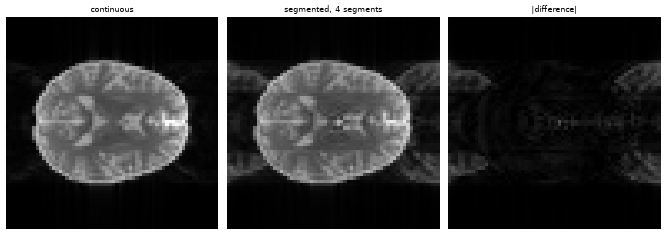

largest difference: 33.1% of the continuous image peak


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
top = max(image.max(), segmented.max())
for ax, (title, data, vmax) in zip(axes, (
    ('continuous', image, top),
    (f'segmented, {SEGMENTS} segments', segmented, top),
    ('|difference|', np.abs(image - segmented), top),
)):
    ax.imshow(data.T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.tight_layout()
plt.show()

rel = np.abs(image - segmented).max() / image.max()
print(f'largest difference: {rel * 100:.1f}% of the continuous image peak')

The two acquisitions encode the same lines and differ only in where the start-up ramps fall — and
the difference is large, not subtle. §1 is why: ten ramp repetitions are nowhere near enough to
settle any of these tissues, so every segment is acquired during a transient, and the segmented
acquisition restarts that transient three extra times.

With `ky` played in linear order, that shows up as a modulation along `ky`. Comparing the two
acquisitions line by line isolates it: both sampled the same object with the same trajectory, so
dividing one by the other removes the object's k-space envelope and leaves the magnetisation.

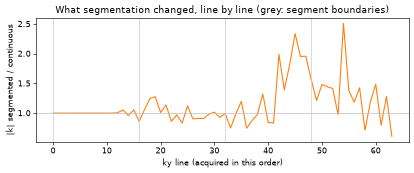

ratio ranges 0.61 to 2.51 over ky
  segment 0: lines  0-15  ratio 0.96 to 1.05
  segment 1: lines 16-31  ratio 0.83 to 1.28
  segment 2: lines 32-47  ratio 0.75 to 2.34
  segment 3: lines 48-63  ratio 0.61 to 2.51


In [10]:
# The object's own k-space falls away from the centre by two orders of magnitude, which would
# swamp what this is about.  The *ratio* of the two acquisitions divides that envelope out: both
# sampled the same object with the same trajectory, so what is left is the magnetisation.
cont_line = np.abs(k_cont[:, :, NX // 2]).sum(axis=0)
seg_line = np.abs(k_seg[:, :, NX // 2]).sum(axis=0)
ratio = seg_line / cont_line

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ratio, lw=1.4, color='C1')
ax.axhline(1.0, color='0.75', lw=0.9)
for boundary in range(0, NY, NY // SEGMENTS):
    ax.axvline(boundary, color='0.8', lw=0.9)
ax.set_xlabel('ky line (acquired in this order)')
ax.set_ylabel('|k| segmented / continuous')
ax.set_title('What segmentation changed, line by line (grey: segment boundaries)')
fig.tight_layout()
plt.show()

print(f'ratio ranges {ratio.min():.2f} to {ratio.max():.2f} over ky')
for seg in range(SEGMENTS):
    lo = seg * (NY // SEGMENTS)
    chunk = ratio[lo:lo + NY // SEGMENTS]
    print(f'  segment {seg}: lines {lo:2d}-{lo + NY // SEGMENTS - 1:2d}  '
          f'ratio {chunk.min():.2f} to {chunk.max():.2f}')

The first segment agrees with the continuous acquisition almost exactly — ratio 0.96 to 1.05 —
which it should, because both start from equilibrium and run the same ten-step ramp. The
disagreement grows with segment index, reaching 0.61 to 2.51 in the last one. By the time the
continuous acquisition reaches those lines it has had fifty-odd repetitions to converge, while
the segmented acquisition has just restarted its transient from a magnetisation the ramp leaves
somewhere else.

So the structure in the difference image is not a boundary effect repeating identically four
times; it is the continuous train pulling away from a segmented train that keeps being reset.
Neither acquisition is less balanced than the other — that holds interval by interval in both,
and the build notebook measures it. What differs is the magnetisation, and every remedy is
acquisition policy living in the build notebook: a longer ramp, a centre-ordered `ky` table so
the transient lands on the k-space periphery, or fewer segments.

In [11]:
mask = ph.same_frame(ph.mask(matrix=NX, nz=NZ)[..., NZ // 2])
print(f'{"":14}{"mean |S| in tissue":>20}{"std":>10}')
for name, data in (('continuous', image), ('segmented', segmented)):
    v = data[mask]
    print(f'{name:14}{v.mean():20.4f}{v.std():10.4f}')

                mean |S| in tissue       std
continuous                  0.8347    0.6812
segmented                   0.8403    0.6009


## 3. What this notebook did and did not establish

**Established, by simulation:**

- Every repetition of every train above plays the same balanced waveform, and the signal still
  changes from one to the next until the magnetisation settles. Balance and steady state are
  separate properties, and only the first is a property of the file.
- An unprepared train opens several times above its final value; a ten-step flip-angle ramp
  removes that opening spike. Neither shortens the $T_1$-scale convergence underneath, for the
  tissues and protocol simulated.
- The steady-state response against off-resonance falls away towards $\pm 1/(2\,\mathrm{TR})$,
  where the phase per TR reaches $\pm\pi$ under the 180° alternation used here.
- A segmented acquisition encodes the same lines as a continuous one, and repeats the start-up
  transient once per segment, which with linear `ky` ordering appears as a modulation across
  k-space.

**Not established here:**

- How many start-up repetitions a protocol needs. The numbers above are for these tissues, this
  flip angle and this TR.
- Which start-up schedule is best; only the linear ramp is simulated.
- What a centre-ordered or interleaved `ky` table would do to the segmented image. Those are
  edits to the build notebook's two loops, and none of them is measured here.
- Anything about a real scanner. MRzero applies each pulse as a rotation by its integrated
  envelope, the phantom's $B_0$ map is synthesised rather than measured, and each simulated voxel
  carries a single off-resonance value rather than a distribution.

## Summary

- A balanced waveform is true from the first RF-to-RF interval. A steady state develops over
  repetitions, on a timescale set by $T_1$.
- `M0 = 0`, legal timing and a successful compile establish the first and say nothing about the
  second.
- The start-up schedule, the `ky` ordering and the segmentation are acquisition policy, written
  in the notebook rather than in the kernel — and in this protocol they are what the image
  quality turns on.

## References

1. Carr HY. *Steady-state free precession in nuclear magnetic resonance.* Phys Rev 1958;112:1693.
2. Scheffler K, Lehnhardt S. *Principles and applications of balanced SSFP techniques.* Eur Radiol
   2003;13:2409.
3. Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.* J Magn Reson
   Imaging 2013;38:2.
4. Deshpande VS, Chung YC, Zhang Q, Shea SM, Li D. *Reduction of transient signal oscillations in
   true-FISP using a linear flip angle series magnetization preparation.* Magn Reson Med
   2003;49:151.
5. Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, §14.1.